In [ ]:
from IPython.display import display, HTML

# Esto hace que el notebook ocupe todo el ancho de la pantalla
display(HTML("<style>.container { width:100% !important; }</style>"))

Se lee la carpeta "data" de la librería, la cual contiene todos los archivos de parámetros "S" para todas las polarizaciones de todos los transistores disponibles.
Se filtra el transistor seleccionado (BFP760) y se guardan los valores de los parámetros para la frecuencia seleccionada (2GHz) en los archivos que se modelan con ruido.
Se genera un archivo .csv para contener todos los datos.

In [ ]:
import pandas as pd

# Mostrar todas las columnas, no importa cuántas sean
pd.set_option('display.max_columns', None)

# Aumentar el ancho total de la consola para que no salte de línea
pd.set_option('display.width', 1000)

# Mostrar el contenido completo de las celdas (sin recortar texto largo)
pd.set_option('display.max_colwidth', None)
from pathlib import Path
import numpy as np


def procesar_transistores_especificos(ruta_carpeta):
    
    folder = Path(ruta_carpeta)
    archivos = list(folder.glob("BFP760_w*.s2p"))
    print("\n")
    print(f"Se encontraron {len(archivos)} archivos que coinciden con el patrón.")
    
    resultados = []
    
    for archivo in archivos:
        try:
            with open(archivo, 'r') as f:
                for linea in f:
                    if linea.strip().startswith("2.000"):
                        partes = linea.split()
                        resultados.append({
                            "Archivo": archivo.name,
                            "S11_MAG": float(partes[1]),
                            "S11_ANG": float(partes[2]),
                            "S21_MAG": float(partes[3]),
                            "S21_ANG": float(partes[4]),
                            "S12_MAG": float(partes[5]),
                            "S12_ANG": float(partes[6]),
                            "S22_MAG": float(partes[7]),
                            "S22_ANG": float(partes[8])
                        })
                        break 
        except Exception as e:
            print(f"Error al procesar {archivo.name}: {e}")
            
    return pd.DataFrame(resultados)

df = procesar_transistores_especificos(r"C:\Users\agust\Desktop\Infineon_RF\circuit\data")

# 1. Verifica cuántas filas tiene realmente tu tabla
print(f"Total de filas procesadas: {len(df)}")

# 2. Exporta todo a un archivo CSV para abrirlo en Excel
df.to_csv(r"C:\Users\agust\Desktop\resultados_2GHz.csv", index=False, sep=';', encoding='utf-8-sig')
print(r"Archivo guardado en: C:\Users\agust\Desktop\resultados_2GHz.csv")



Se encontraron 84 archivos que coinciden con el patrón.
Total de filas procesadas: 84
Archivo guardado en: C:\Users\agust\Desktop\resultados_2GHz.csv


Luego se convierten los datos a forma rectangular, se calcula el factor de Rollet "k" y el $\Delta$, necesarios para analizar la estabilidad de dicha polarización, y se ordena de mayor a menor según "k".

In [ ]:
# 1. Convertir los datos a números complejos (Rectangulares)
def to_complex(mag, ang):
    return mag * np.exp(1j * np.radians(ang))

# Aplicamos la conversión a las columnas del DataFrame
df['S11_C'] = to_complex(df['S11_MAG'], df['S11_ANG'])
df['S21_C'] = to_complex(df['S21_MAG'], df['S21_ANG'])
df['S12_C'] = to_complex(df['S12_MAG'], df['S12_ANG'])
df['S22_C'] = to_complex(df['S22_MAG'], df['S22_ANG'])

# 2. Calcular Delta
df['Delta'] = (df['S11_C'] * df['S22_C']) - (df['S12_C'] * df['S21_C'])
df['ABS_DELTA'] = np.abs(df['Delta'])

# 3. Calcular el Factor de Rollet (K)
num = 1 - (np.abs(df['S11_C'])**2) - np.abs((df['S22_C'])**2) + (df['ABS_DELTA']**2)
den = 2 * np.abs(df['S12_C'] * df['S21_C'])
df['K'] = num / den

df_final = df.sort_values(by='K', ascending=False)

print("\n--- Ranking de Estabilidad (de mayor a menor K) ---")
print(df_final[['Archivo', 'K', 'ABS_DELTA', 'S21_MAG']].head(30))



--- Ranking de Estabilidad (de mayor a menor K) ---
                                Archivo         K  ABS_DELTA  S21_MAG
9   BFP760_w_noise_VCE_1.0V_IC_40mA.s2p  0.799868   0.473693    9.264
21  BFP760_w_noise_VCE_1.5V_IC_40mA.s2p  0.773820   0.478892   11.313
33  BFP760_w_noise_VCE_2.0V_IC_40mA.s2p  0.767607   0.476737   11.888
45  BFP760_w_noise_VCE_2.5V_IC_40mA.s2p  0.764817   0.472618   12.150
81  BFP760_w_noise_VCE_4.0V_IC_40mA.s2p  0.762781   0.459097   12.496
57  BFP760_w_noise_VCE_3.0V_IC_40mA.s2p  0.762006   0.468256   12.312
69  BFP760_w_noise_VCE_3.5V_IC_40mA.s2p  0.761821   0.464165   12.420
7   BFP760_w_noise_VCE_1.0V_IC_35mA.s2p  0.755298   0.497707   10.028
19  BFP760_w_noise_VCE_1.5V_IC_35mA.s2p  0.742931   0.483013   11.460
31  BFP760_w_noise_VCE_2.0V_IC_35mA.s2p  0.739417   0.475098   11.913
43  BFP760_w_noise_VCE_2.5V_IC_35mA.s2p  0.736842   0.470021   12.137
55  BFP760_w_noise_VCE_3.0V_IC_35mA.s2p  0.736350   0.463300   12.278
79  BFP760_w_noise_VCE_4.0V_IC_35mA.s

Se calcula la MSG (Maximum Stable Gain) en dB como figura de mérito, para cada polarización. Ordena el data frame de mayor a menor según el valor de MSG.

In [ ]:
# 1. Obtiene los módulos de S21 y S12

s21_mag = np.abs(df_final['S21_C'])
s12_mag = np.abs(df_final['S12_C'])

# 2. Aplicamos la fórmula
df_final['MSG_dB'] = 10 * np.log10(s21_mag / s12_mag)

df_final_Gain = df_final.sort_values(by='MSG_dB', ascending=False)

print("\n--- Ranking de MSG (de mayor a menor) ---")
print(df_final_Gain[['Archivo', 'K', 'MSG_dB']].head(40))


--- Ranking de MSG (de mayor a menor) ---
                                Archivo         K     MSG_dB
81  BFP760_w_noise_VCE_4.0V_IC_40mA.s2p  0.762781  25.181318
69  BFP760_w_noise_VCE_3.5V_IC_40mA.s2p  0.761821  25.131966
57  BFP760_w_noise_VCE_3.0V_IC_40mA.s2p  0.762006  25.071298
79  BFP760_w_noise_VCE_4.0V_IC_35mA.s2p  0.734773  25.008466
45  BFP760_w_noise_VCE_2.5V_IC_40mA.s2p  0.764817  24.991155
67  BFP760_w_noise_VCE_3.5V_IC_35mA.s2p  0.734072  24.961586
55  BFP760_w_noise_VCE_3.0V_IC_35mA.s2p  0.736350  24.936314
33  BFP760_w_noise_VCE_2.0V_IC_40mA.s2p  0.767607  24.862771
43  BFP760_w_noise_VCE_2.5V_IC_35mA.s2p  0.736842  24.842283
78  BFP760_w_noise_VCE_4.0V_IC_30mA.s2p  0.700491  24.780712
66  BFP760_w_noise_VCE_3.5V_IC_30mA.s2p  0.699678  24.757807
31  BFP760_w_noise_VCE_2.0V_IC_35mA.s2p  0.739417  24.728768
54  BFP760_w_noise_VCE_3.0V_IC_30mA.s2p  0.699741  24.694663
42  BFP760_w_noise_VCE_2.5V_IC_30mA.s2p  0.702199  24.626859
21  BFP760_w_noise_VCE_1.5V_IC_40mA.s2p  0

Se calculan los coeficientes de reflexión de la fuente y de la carga ($\Gamma_S$ y $\Gamma_L$, respectivamente) y sus magnitudes, tal de verificar que éstas sean menores a 1.

--- ANALIZANDO POLARIZACIÓN: BFP760_w_noise_VCE_1.0V_IC_40mA.s2p (Fila 0) ---
Punto 1: G_L = 0.240∠-157.0°  -->  G_S = 0.644∠-178.4°
Punto 2: G_L = 0.000∠0.0°  -->  G_S = 0.715∠-172.8°
Punto 3: G_L = 0.590∠180.0°  -->  G_S = 0.640∠164.7°
Punto 4: G_L = 0.330∠-90.0°  -->  G_S = 0.612∠-167.3°
Punto 5: G_L = 0.750∠-90.0°  -->  G_S = 0.526∠-155.9°
Punto 6: G_L = 0.750∠90.0°  -->  G_S = 1.006∠-175.4°
Punto 7: G_L = 0.750∠0.0°  -->  G_S = 0.823∠-157.7°
Punto 8: G_L = 0.950∠0.0°  -->  G_S = 0.849∠-155.0°
Punto 9: G_L = 0.950∠180.0°  -->  G_S = 0.639∠143.2°
Punto 10: G_L = 0.750∠45.0°  -->  G_S = 0.934∠-164.6°
Punto 11: G_L = 0.950∠45.0°  -->  G_S = 0.979∠-162.6°
Punto 12: G_L = 0.750∠135.0°  -->  G_S = 0.947∠168.3°
Punto 13: G_L = 0.950∠135.0°  -->  G_S = 1.061∠165.0°
Punto 14: G_L = 0.750∠-45.0°  -->  G_S = 0.688∠-153.8°
Punto 15: G_L = 0.950∠-45.0°  -->  G_S = 0.699∠-149.9°
Punto 16: G_L = 0.750∠-135.0°  -->  G_S = 0.405∠-179.1°
Punto 17: G_L = 0.950∠-135.0°  -->  G_S = 0.311∠-178.0°


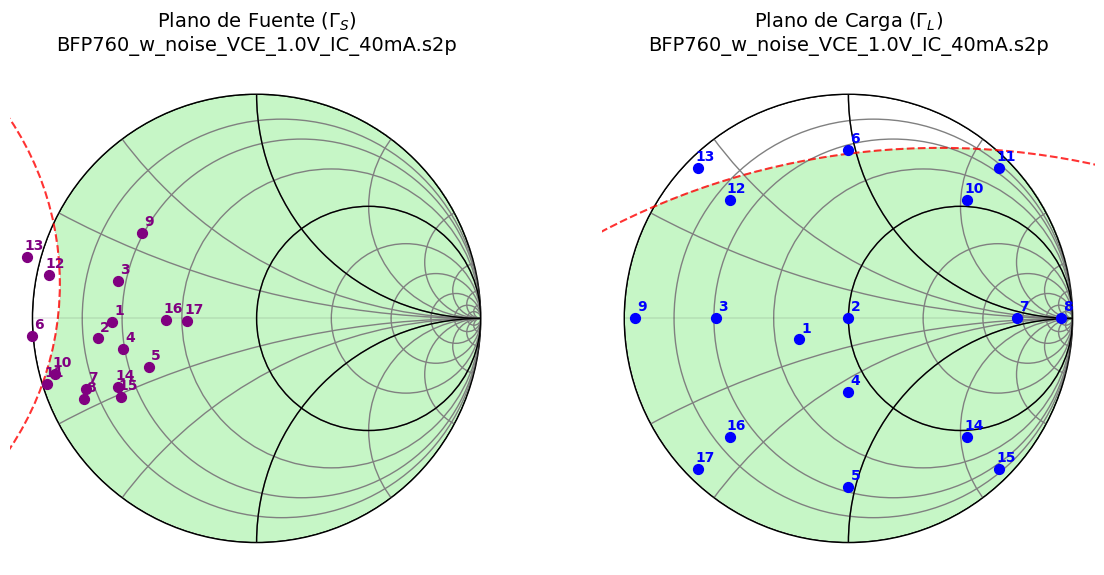

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf
from matplotlib.patches import Circle

def pintar_zona_estable(ax, centro, radio, origen_estable):
    """
    Pinta exclusivamente el área segura/estable en verde dentro de la Carta de Smith.
    """
    # 1. Creamos la grilla de píxeles
    x = np.linspace(-1.1, 1.1, 500)
    y = np.linspace(-1.1, 1.1, 500)
    X, Y = np.meshgrid(x, y)
    Gamma = X + 1j * Y
    
    # 2. Condiciones lógicas
    en_carta_smith = np.abs(Gamma) <= 1.0
    dist_al_centro = np.abs(Gamma - centro)
    origen_dentro_circulo = np.abs(centro) < radio
    
    estable_adentro = (origen_estable == origen_dentro_circulo)
    
    if estable_adentro:
        es_estable = dist_al_centro <= radio
    else:
        es_estable = dist_al_centro >= radio
        
    # 3. Matriz de la zona estable
    zona_a_pintar = np.logical_and(en_carta_smith, es_estable)
    color = [0.56, 0.93, 0.56, 0.5]  # Verde claro (lightgreen) con alpha=0.5
        
    # 4. Crea una imagen RGBA transparente y le inyectamos el color
    imagen_rgba = np.zeros((500, 500, 4))
    imagen_rgba[zona_a_pintar] = color
    
    # Plotea la imagen de fondo (zorder=0)
    ax.imshow(imagen_rgba, extent=[-1.1, 1.1, -1.1, 1.1], origin='lower', zorder=0)

    # 5. Dibuja el borde del círculo de inestabilidad con línea punteada roja
    borde_circulo = Circle((np.real(centro), np.imag(centro)), radio, 
                           fill=False, edgecolor='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.add_patch(borde_circulo)
    
def analizar_polarizacion(df, fila_elegida, puntos_gamma_L):
    
    # 1. Extrae los datos EXACTOS de la fila
    transistor = df.iloc[fila_elegida]
    S11 = transistor['S11_C']
    S21 = transistor['S21_C']
    S12 = transistor['S12_C']
    S22 = transistor['S22_C']
    K   = transistor['K']  # Toma el K de esta fila
    archivo = transistor.get('Archivo', f'Fila {fila_elegida}') 
    
    print(f"--- ANALIZANDO POLARIZACIÓN: {archivo} (Fila {fila_elegida}) ---")

    # 2. Cálculos de Gammas
    Gamma_L_array = np.array([to_complex(mag, ang) for mag, ang in puntos_gamma_L])
    Gamma_in_array = S11 + (S12 * S21 * Gamma_L_array) / (1 - S22 * Gamma_L_array)
    Gamma_S_array = np.conj(Gamma_in_array)

    # Imprime los resultados en consola
    for i in range(len(Gamma_L_array)):
        print(f"Punto {i+1}: G_L = {np.abs(Gamma_L_array[i]):.3f}∠{np.angle(Gamma_L_array[i], deg=True):.1f}°  -->  G_S = {np.abs(Gamma_S_array[i]):.3f}∠{np.angle(Gamma_S_array[i], deg=True):.1f}°")

    # 3. GUARDAR LOS DATOS EN EL DATAFRAME
    if 'Gamma_L_Test' not in df.columns:
        df['Gamma_L_Test'] = None
        df['Gamma_S_Test'] = None
        
    df.at[df.index[fila_elegida], 'Gamma_L_Test'] = Gamma_L_array
    df.at[df.index[fila_elegida], 'Gamma_S_Test'] = Gamma_S_array

    # 4. Fórmulas de Gonzalez
    Delta = (S11 * S22) - (S12 * S21)

    Cs_num = S11 - Delta * np.conj(S22)
    Cs_den = np.abs(S11)**2 - np.abs(Delta)**2
    C_S = np.conj(Cs_num) / Cs_den  
    R_S = np.abs(S12 * S21) / np.abs(Cs_den)  

    Cl_num = S22 - Delta * np.conj(S11)
    Cl_den = np.abs(S22)**2 - np.abs(Delta)**2
    C_L = np.conj(Cl_num) / Cl_den  
    R_L = np.abs(S12 * S21) / np.abs(Cl_den)  

    # 5. Graficación
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    # --- Plano de Fuente (Entrada) ---
    rf.plotting.smith(ax=ax1)
    ax1.set_title(f'Plano de Fuente ($\\Gamma_S$)\n{archivo}', fontsize=14, pad=15)
    origen_estable_S = np.abs(S22) < 1  
    pintar_zona_estable(ax1, C_S, R_S, origen_estable_S)
    ax1.plot(np.real(C_S), np.imag(C_S), marker='x', color='red')
    ax1.set_aspect('equal')
    ax1.set_xlim(-1.1, 1.1)
    ax1.set_ylim(-1.1, 1.1)

    # --- Plano de Carga (Salida) ---
    rf.plotting.smith(ax=ax2)
    ax2.set_title(f'Plano de Carga ($\\Gamma_L$)\n{archivo}', fontsize=14, pad=15)
    origen_estable_L = np.abs(S11) < 1  
    pintar_zona_estable(ax2, C_L, R_L, origen_estable_L)
    ax2.plot(np.real(C_L), np.imag(C_L), marker='x', color='red')
    ax2.set_aspect('equal')
    ax2.set_xlim(-1.1, 1.1)
    ax2.set_ylim(-1.1, 1.1)

    # Puntos de Prueba
    ax1.scatter(np.real(Gamma_S_array), np.imag(Gamma_S_array), color='purple', s=50, zorder=5, label='$\\Gamma_S$ resultantes')
    ax2.scatter(np.real(Gamma_L_array), np.imag(Gamma_L_array), color='blue', s=50, zorder=5, label='$\\Gamma_L$ elegidos')

    for i in range(len(Gamma_L_array)):
        ax1.annotate(str(i+1), (np.real(Gamma_S_array[i]), np.imag(Gamma_S_array[i])), textcoords="offset points", xytext=(5,5), ha='center', fontsize=10, color='purple', weight='bold')
        ax2.annotate(str(i+1), (np.real(Gamma_L_array[i]), np.imag(Gamma_L_array[i])), textcoords="offset points", xytext=(5,5), ha='center', fontsize=10, color='blue', weight='bold')


puntos_prueba = [
    (0.24, -157), 
    (0, 0), 
    (0.59, 180),
    (0.33, -90), 
    (0.75, -90), 
    (0.75, 90),
    (0.75, 0), 
    (0.95, 0), 
    (0.95, 180), 
    (0.75, 45), 
    (0.95, 45), 
    (0.75, 135), 
    (0.95, 135), 
    (0.75, -45), 
    (0.95, -45), 
    (0.75, -135), 
    (0.95, -135)
]

fila_a_evaluar = 0

analizar_polarizacion(df_final, fila_a_evaluar, puntos_prueba)

A continuación hay un espacio para seleccionar un $\Gamma_L$, calcular los coeficientes restantes, y obtener las impedancias de entrada y salida del transistor.

In [ ]:
# 1.    (0.24, -157), 
# 2.    (0, 0), 
# 3.    (0.59, 180),
# 4.    (0.33, -90), 
# 5.    (0.75, -90), 
# 6.    (0.75, 90),
# 7.    (0.75, 0), 
# 8.    (0.95, 0), 
# 9.    (0.95, 180), 
# 10.   (0.75, 45), 
# 11.   (0.95, 45), 
# 12.   (0.75, 135), 
# 13.   (0.95, 135), 
# 14.   (0.75, -45), 
# 15.   (0.95, -45), 
# 16.   (0.75, -135), 
# 17.   (0.95, -135)

S11 = df_final['S11_C'].iloc[fila_a_evaluar]
S12 = df_final['S12_C'].iloc[fila_a_evaluar]
S21 = df_final['S21_C'].iloc[fila_a_evaluar]
S22 = df_final['S22_C'].iloc[fila_a_evaluar]

Gamma_L = to_complex(0.95, -45)
Gamma_in = S11 + (S12 * S21 * Gamma_L) / (1 - S22 * Gamma_L)
Gamma_S = np.conj(Gamma_in)
Gamma_out = S22 + (S12 * S21 * Gamma_S) / (1 - S11 * Gamma_S)

Z0 = 50
zin = Z0 * (1 + Gamma_in) / (1 - Gamma_in)
zout = Z0 * (1 + Gamma_out) / (1 - Gamma_out)


Rin = np.real(zin)
Xin = np.imag(zin)
Rout = np.real(zout)
Xout = np.imag(zout)

print('S11 = ', S11, " -> |S11| = ", np.abs(S11))
print('S12 = ', S12, " -> |S12| = ", np.abs(S12))
print('S21 = ', S21, " -> |S21| = ", np.abs(S21))
print('S22 = ', S22, " -> |S22| = ", np.abs(S22))
print("\n")

print('G_L = ', Gamma_L)
print('G_in = ', Gamma_in)
print('G_out = ', Gamma_out)
print('G_S = ', Gamma_S)
print("\n")

print('Rin = ', Rin)
print('Xin = ', Xin)
print('Rout = ', Rout)
print('Xout = ', Xout)

S11 =  (-0.7090643770294573+0.08957566202840814j)  -> |S11| =  0.7147000000000001
S12 =  (0.03460930049461737+0.021794639691292854j)  -> |S12| =  0.040900000000000006
S21 =  (2.5690429481932266+8.900658084115951j)  -> |S21| =  9.264
S22 =  (-0.31677807880153175-0.08428812959610953j)  -> |S22| =  0.32780000000000004


G_L =  (0.6717514421272202-0.6717514421272202j)
G_in =  (-0.6041552899651836+0.35072713058762783j)
G_out =  (0.10450737202740612-0.2714653874632308j)
G_S =  (-0.6041552899651836-0.35072713058762783j)


Rin =  9.494165384007362
Xin =  13.007604714062039
Rout =  52.27182654107707
Xout =  -31.003338443335014
ZLL =  (8.720975229895402-120.17082435770261j)
ZS =  (9.494165384007362-13.007604714062039j)


En este apartado se calcula la adaptacion a la entrada del circuito y la impedancia característica del transformador $\lambda$/4.

In [ ]:
# Adaptación de entrada

R_gen = 50
frecuencia_hz = 2e9  # 2 GHz
omega = 2 * np.pi * frecuencia_hz

if Xin > 0:

    # 1. Aplicamos las fórmulas para Zin_paralelo
    Rin_p = Rin * (1 + (Xin / Rin)**2)
    Xin_p = Xin * (1 + (Rin / Xin)**2)

    # 2. Calculamos la capacitancia necesaria (C)
    C_input_pF = (1 / (omega * Xin_p)) * 1e12

    Zo_in = np.sqrt(R_gen*Rin_p)

    print('Rin paralelo = ', Rin_p)
    print('Xin paralelo = ', Xin_p)

    print('Zo_in = ', Zo_in)
    print('Capacitor de adaptacion de entrada = ', C_input_pF, " [pF]")

else:
    R_L = 50
    Zo_in = np.sqrt(R_L * Rin)

    Xin_traf = Zo_in**(2)/-Xin

    C_input_pF = (1 / (omega * Xin_traf)) * 1e12

    print('Zo_in = ', Zo_in)
    print('Xin transformada = ', Xin_traf)
    print('Capacitor de adaptacion de entrada = ', C_input_pF, " [pF]")


Rin paralelo =  27.315403328976974
Xin paralelo =  19.937333770283864
Zo_in =  36.95632782689385
Capacitor de adaptacion de entrada =  3.9913798135112764  [pF]


En este apartado se calcula el capacitor para la adaptacion a la salida del circuito y la impedancia característica del transformador $\lambda$/4.

In [ ]:
# Adaptación a la salida

R_L = 50
Zo_out = np.sqrt(R_L * Rout)

Xout_traf = Zo_out**(2)/-Xout

C_output_pF = (1 / (omega * Xout_traf)) * 1e12

print('Zo_out = ', Zo_out)
print('Xout transformada = ', Xout_traf)
print('Capacitor de adaptacion de salida = ', C_output_pF, " [pF]")

Zo_out =  51.123295346190794
Xout transformada =  84.30031920048641
Capacitor de adaptacion de salida =  0.9439759220447709  [pF]


A continuación se obtienen los largos y anchos correspondientes para las tiras de los transformadores y las lineas principales.


In [ ]:
import scipy.optimize as opt

# Parámetros del sustrato
h = 1.57    # mm
t = 0.0275  # mm
er = 4
f = 2e9     # Hz

def calcular_We(w, h, t):
    # Calcula el ancho efectivo (We) considerando el espesor del cobre (t).
    if w / h <= 1 / (2 * np.pi):
        return w + (t / np.pi) * (1 + np.log(4 * np.pi * w / t))
    else:
        return w + (t / np.pi) * (1 + np.log(2 * h / t))

def z0_microstrip_wheeler(w, h, er_eff):
    
    u = w / h

    # Cálculo de Z0 (Wheeler)
    if u <= 1:
        z0 = (60 / np.sqrt(er_eff)) * np.log(8 / u + u / 4)
    else:
        z0 = 120 * np.pi / (np.sqrt(er_eff) * (u + 1.393 + 0.667 * np.log(u + 1.444)))
    return z0

def calcular_er_eff(w, h, er):

    u = w / h
    
    # Permitividad efectiva (Hammerstad )
    if u <= 1:
        er_eff = (er + 1) / 2 + (er - 1) / 2 * (1 / np.sqrt(1 + 12 / u) + 0.04 * (1 - u)**2)
    else:
        er_eff = (er + 1) / 2 + (er - 1) / 2 * (1 / np.sqrt(1 + 12 / u))
    
    return er_eff

def calcular_ancho(Zo, er, h):

    A = Zo / 60 * np.sqrt((er + 1)/2) + (er - 1) / (er + 1) * (0.23 + 0.11 / er)

    B = 377 * np.pi / (2 * Zo * np.sqrt(er))

    W_H = 8 * np.exp(A) / (np.exp(2 * A) - 2)

    if W_H >= 2:
        W_H = 2 / np.pi * (B - 1 - np.log(2 * B - 1) + (er - 1) / (2 * er) * (np.log(B - 1) + 0.39 - 0.61 / er))

    W = W_H * h

    er_eff = calcular_er_eff(W, h, er)

    Zo_final = z0_microstrip_wheeler(W, h, er_eff)

    We = calcular_We(W, h, t)

    return [A, B, W_H, W, er_eff, Zo_final, We]

print("\n")

# 1. Calcula ancho para trafos

[A_in, B_in, W_H_in, W_in, er_eff_in, Zo_final_in, We_in] = calcular_ancho(Zo_in, er, h)

[A_out, B_out, W_H_out, W_out, er_eff_out, Zo_final_out, We_out] = calcular_ancho(Zo_out, er, h)

def largo_trafo(Zo, f, er_eff):

    lambda_real = 300 / (f / 1e6)
    lambda_eff = lambda_real / np.sqrt(er_eff)
    beta = 2 * np.pi / lambda_eff
    L = lambda_eff / 4

    return L

d_trafo_in = largo_trafo(Zo_final_in, f, er_eff_in) * 1000 # mm

d_trafo_out = largo_trafo(Zo_final_out, f, er_eff_out) * 1000 # mm


print("Ancho efectivo del transformador de entrada: ", We_in, " [mm]")
print("Ancho efectivo del transformador de salida: ", We_out, " [mm]")
print("Largo del transformador de entrada: ", d_trafo_in, " [mm]")
print("Largo del transformador de salida: ", d_trafo_out, " [mm]")
print("er_eff_in: ", er_eff_in)
print("er_eff_out: ", er_eff_out)


# 2. Calcula ancho para líneas principales:

Zo = 50

[A_p, B_p, W_H_p, W_p, er_eff_p, Zo_final_p, We_p] = calcular_ancho(Zo, er, h)

print("\nAncho de líneas de 50 Ohm : ", We_p, " [mm]")
print("er_eff_p: ", er_eff_p)





Ancho efectivo del transformador de entrada:  5.169426675026089  [mm]
Ancho efectivo del transformador de salida:  3.156141109025023  [mm]
Largo del transformador de entrada:  20.984934120686116  [mm]
Largo del transformador de salida:  21.422280648053377  [mm]
er_eff_in:  3.1933558393297554
er_eff_out:  3.0642989068829642

Ancho de líneas de 50 Ohm :  3.273597366630092  [mm]
er_eff_p:  3.073337699935324


En este apartado se obtienen los largos y anchos de los stubs de adaptación.

In [ ]:
Z_stub = 50 

def calcular_largo_stub(C_pF, Z_stub, f, er_eff):

    omega = 2 * np.pi * f
    C = C_pF * 1e-12
    Xc = 1 / (omega * C)
    
    lambda_eff = 300 / ((f / 1e6) * np.sqrt(er_eff))
    
    beta = 2 * np.pi / lambda_eff

    # Largo en mm
    d =  np.arctan(Z_stub / Xc) / beta * 1000
    return d

propiedades_stub = calcular_ancho(Z_stub, er, h)

We_stub_mm = propiedades_stub[6]      # Weff está en la posición 6
er_eff_stub = propiedades_stub[4]    # er_eff está en la posición 4


d_C_in = calcular_largo_stub(C_input_pF, Z_stub, f, er_eff_stub)

d_C_out = calcular_largo_stub(C_output_pF, Z_stub, f, er_eff_stub)

print("\n--- Resultados de Stubs ---")
print('Ancho de stubs: ', We_stub_mm," [mm]")
print("Largo de stub de entrada: ", d_C_in, " [mm]")
print("Largo de stub de salida: ", d_C_out, " [mm]")



--- Resultados de Stubs ---
Ancho de stubs:  3.273597366630092  [mm]
Largo de stub de entrada:  16.223823970250187  [mm]
Largo de stub de salida:  7.290189149172177  [mm]


Se apuntan los datos de longitud de las microtiras diseñadas:

In [ ]:
print("\n--- Resultados de Tiras ---")

long_traf_in = 20.98493412068
long_traf_out = 21.422280648
long_stub_in = 16.22382397025018
long_stub_out = 7.29018914917


print("Largo de transformador de entrada fino: ", long_traf_in, " [mm]")
print("Largo de transformador de salida fino: ", long_traf_out, " [mm]")
print("Largo de stub de entrada fino: ", long_stub_in, " [mm]")
print("Largo de stub de salida fino: ", long_stub_out, " [mm]")


--- Resultados de Tiras ---
Largo de transformador de entrada fino:  20.98493412068  [mm]
Largo de transformador de salida fino:  21.422280648  [mm]
Largo de stub de entrada fino:  16.22382397025018  [mm]
Largo de stub de salida fino:  7.29018914917  [mm]


Calculadora de Tapers de los stubs:

In [ ]:
# Fijo un valor para el largo del taper y para la punta
long_taper = 3 # [mm]
punta_taper = 0.5 # [mm]

def diferencia_long(We_tira, long_taper, punta_taper):

    area_recortada = ((We_tira - punta_taper) * long_taper)
    long_a_agregar = area_recortada/We_tira
    diferencia = long_a_agregar - 3

    return diferencia

print("\n Diferencia de largo de los C de adaptación: ",  diferencia_long(We_stub_mm, long_taper, punta_taper), " [mm].")

print("\n Largo final de la tira del C de adaptación de entrada: ",  long_stub_in  + diferencia_long(We_stub_mm, long_taper, punta_taper), " [mm].")
print("\n Largo final de la tira del C de adaptación de salida: ",  long_stub_out  + diferencia_long(We_stub_mm, long_taper, punta_taper), " [mm].")




 Diferencia de largo de los C de adaptación:  -0.4582115122924022  [mm].

 Largo final de la tira del C de adaptación de entrada:  15.765612457957777  [mm].

 Largo final de la tira del C de adaptación de salida:  6.831977636877598  [mm].


Síntesis de microtiras del inductor de choque y capacitor de desacople.

In [ ]:
Z_Lch = 100

propiedades_Lch = calcular_ancho(Z_Lch, er, h)

We_Lch = propiedades_Lch[6]      # W está en la posición 3
er_eff_Lch = propiedades_Lch[4]    # er_eff está en la posición 4
lambda_eff_Lch  = 300 / ((f / 1e6) * np.sqrt(er_eff_Lch)) * 1000

d_Lch = lambda_eff_Lch / 4


Z_Cdec = 40

propiedades_Cdec = calcular_ancho(Z_Cdec, er, h)


We_Cdec = propiedades_Cdec[6]      # W está en la posición 3
er_eff_Cdec = propiedades_Cdec[4]    # er_eff está en la posición 4
lambda_eff_Cdec  = 300 / ((f / 1e6) * np.sqrt(er_eff_Cdec)) * 1000

d_Cdec = lambda_eff_Cdec / 4

print('Ancho de linea de Lch: ', We_Lch," [mm]")
print('Ancho de linea de Cdec: ', We_Cdec," [mm]")
print("Largo de la linea para Lch: ", d_Lch, " [mm]")
print("Largo de la linea para Cdec: ", d_Cdec, " [mm]")

Ancho de linea de Lch:  0.8277532860030835  [mm]
Ancho de linea de Cdec:  4.610590907806128  [mm]
Largo de la linea para Lch:  22.35506689224447  [mm]
Largo de la linea para Cdec:  21.088106585720958  [mm]


Calculadora con tapers de los inductores de choque y capacitores de desacople.

In [ ]:
print("\n Diferencia de largo de los Lch: ",  diferencia_long(We_Lch, long_taper, punta_taper), " [mm].")
print("\n Diferencia de largo de los Cdec: ",  diferencia_long(We_Cdec, long_taper, punta_taper), " [mm].")

print("\n Largo final de la tira del Lch: ",  d_Lch + diferencia_long(We_Lch, long_taper, punta_taper), " [mm].")
print("\n Largo final de la tira del Cdec: ",  d_Cdec  + diferencia_long(We_Cdec, long_taper, punta_taper), " [mm].")



 Diferencia de largo de los Lch:  -1.812134153212425  [mm].

 Diferencia de largo de los Cdec:  -0.3253379078721492  [mm].

 Largo final de la tira del Lch:  20.542932739032043  [mm].

 Largo final de la tira del Cdec:  20.762768677848808  [mm].
